In [1]:
from google.colab import files
uploaded = files.upload()

Saving loan_data_preprocessed.csv to loan_data_preprocessed.csv


In [2]:
import pandas as pd

df = pd.read_csv("loan_data_preprocessed.csv")
df.head()

,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,...,credit_type_CRIF,credit_type_EQUI,credit_type_EXP,co-applicant_credit_type_EXP,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct,Status
0,0.0,-1.166984,-0.085757,-0.086620,-0.164746,0.425616,-1.087010,-0.816468,0.502330,0.679314,...,-0.647335,-0.338645,1.611860,-0.999207,0.740558,-0.091525,-0.249269,1.149956,0.0149,1
1,0.0,-0.677612,-0.085757,-0.086620,-0.164746,0.425616,-0.209879,-0.302187,-1.275447,0.056662,...,-0.647335,2.952949,-0.620401,1.000794,0.740558,-0.091525,-0.249269,-0.869599,0.0149,1
2,0.0,0.409881,1.081433,-0.513611,-0.880061,0.425616,0.053260,0.412093,1.158210,0.185553,...,-0.647335,-0.338645,1.611860,-0.999207,0.740558,-0.091525,-0.249269,1.149956,0.0149,0
3,0.0,0.681754,0.446645,0.565079,-0.164746,0.425616,0.491826,0.793042,-0.973398,-0.095326,...,-0.647335,-0.338645,1.611860,-0.999207,-1.350332,-0.091525,-0.249269,-0.869599,0.0149,0
4,0.0,1.986746,-0.065280,-0.279932,-1.092713,0.425616,0.784203,0.564472,-0.843948,0.498737,...,1.544795,-0.338645,-0.620401,1.000794,-1.350332,-0.091525,-0.249269,-0.869599,0.0149,0


In [3]:
X = df.drop("Status", axis=1)
y = df["Status"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [6]:
y_pred = model.predict(X_test)

In [7]:
#Evaluate Model Performance

In [8]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8701486513755297

In [9]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[22117,   288],
       [ 3573,  3756]])

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22405
           1       0.93      0.51      0.66      7329

    accuracy                           0.87     29734
   macro avg       0.89      0.75      0.79     29734
weighted avg       0.88      0.87      0.86     29734



In [11]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.8582859500867339)

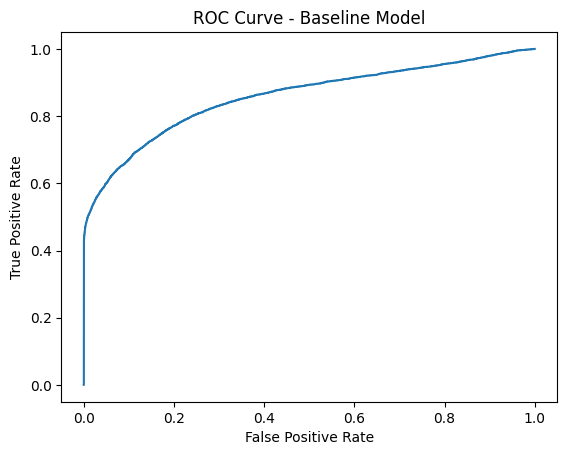

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Model")
plt.show()